https://raw.githubusercontent.com/datasets/covid-19/master/data/countries-aggregated.csv

In [77]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('https://raw.githubusercontent.com/datasets/covid-19/refs/heads/main/data/countries-aggregated.csv')

In [78]:
df['Date'] = pd.to_datetime(df['Date'])

### Check the dataset using head(), info(), and describe()

In [108]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 161568 entries, 0 to 161567
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   Date       161568 non-null  datetime64[us]
 1   Country    161568 non-null  str           
 2   Confirmed  161568 non-null  int64         
 3   Recovered  161568 non-null  int64         
 4   Deaths     161568 non-null  int64         
dtypes: datetime64[us](1), int64(3), str(1)
memory usage: 6.2 MB


In [109]:
df.isnull().sum()

Date         0
Country      0
Confirmed    0
Recovered    0
Deaths       0
dtype: int64

In [110]:
df.describe()

,Date,Confirmed,Recovered,Deaths
count,161568,1.615680e+05,1.615680e+05,161568.000000
mean,2021-03-04 12:00:00,7.361569e+05,1.453967e+05,13999.436089
min,2020-01-22 00:00:00,0.000000e+00,0.000000e+00,0.000000
25%,2020-08-12 18:00:00,1.220000e+03,0.000000e+00,17.000000
50%,2021-03-04 12:00:00,2.369200e+04,1.260000e+02,365.000000
75%,2021-09-24 06:00:00,2.558420e+05,1.797225e+04,4509.000000
max,2022-04-16 00:00:00,8.062512e+07,3.097475e+07,988609.000000
std,NaN,3.578884e+06,9.748275e+05,59113.581271


In [82]:
df.columns

Index(['Date', 'Country', 'Confirmed', 'Recovered', 'Deaths'], dtype='str')

### Filter data for India

In [111]:
filter_country = df[df['Country']  == 'India'].copy()  #copy is a good practice

In [84]:
filter_country[filter_country['Confirmed'] == 1].value_counts()

Date        Country  Confirmed  Recovered  Deaths
2020-01-30  India    1          0          0         1
2020-01-31  India    1          0          0         1
2020-02-01  India    1          0          0         1
Name: count, dtype: int64

### Calculate daily increase using diff()

In [112]:
filter_country['Confirmed'].diff().fillna(0)

65280       0.0
65281       0.0
65282       0.0
65283       0.0
65284       0.0
          ...  
66091    1088.0
66092    1007.0
66093     949.0
66094     975.0
66095    1150.0
Name: Confirmed, Length: 816, dtype: float64

In [113]:
filter_country['Daily_case'] = filter_country['Confirmed'].diff().fillna(0)

### Create a line plot of daily confirmed cases for India

In [114]:
filter_country['Date'] = pd.to_datetime(filter_country['Date'])
#we need this conversion for using date properties on the plot

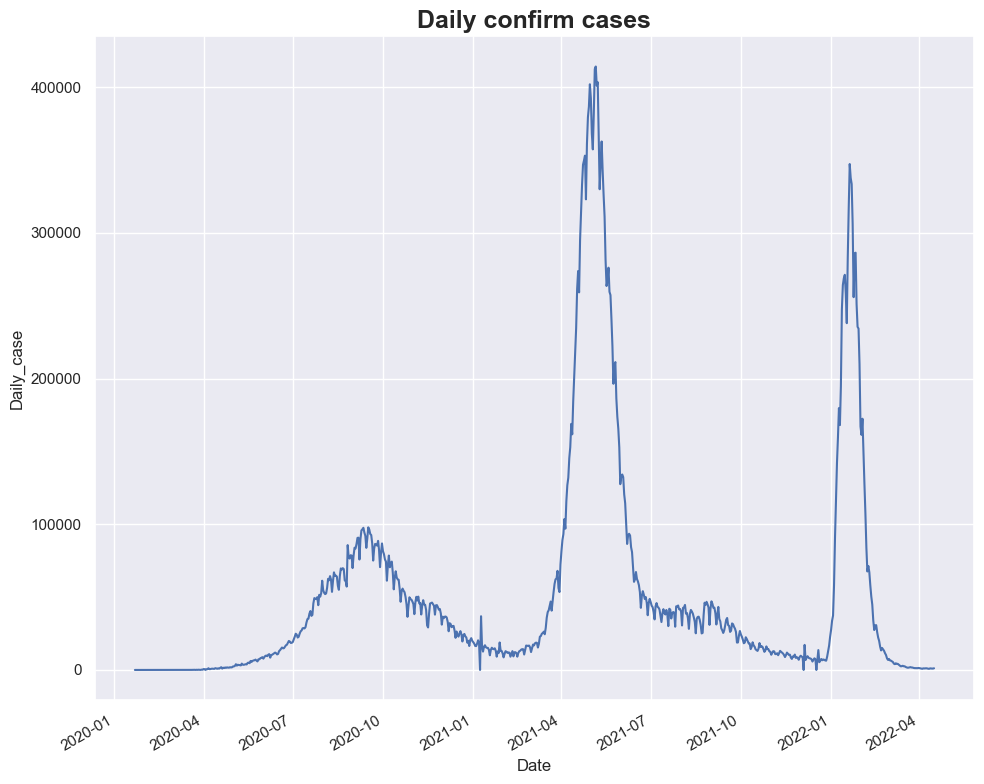

In [115]:
sns.set_theme(style='darkgrid')
plt.figure(figsize = (10,8))
sns.lineplot(data = filter_country, x = 'Date', y = 'Daily_case')
plt.title('Daily confirm cases', fontsize=18, fontweight='bold' )
plt.gcf().autofmt_xdate()  #kamaal function hai zyada data points ke liye
plt.tight_layout()
plt.show()

In [89]:
filter_country['Daily_case'].max()

np.float64(414188.0)

### Compare Multiple Countries
1. Countries: India, Pakistan, Italy  
2. Create a line plot comparing daily confirmed cases  

In [90]:
countries = ['Pakistan','India','Italy']
multiple_country = df[df['Country'].isin(countries)].copy()

In [ ]:
multiple_country.groupby('Country')['Confirmed'].diff().fillna(0)

In [ ]:
multiple_country['Daily_cases'] = multiple_country.groupby('Country')['Confirmed'].diff().fillna(0)
multiple_country

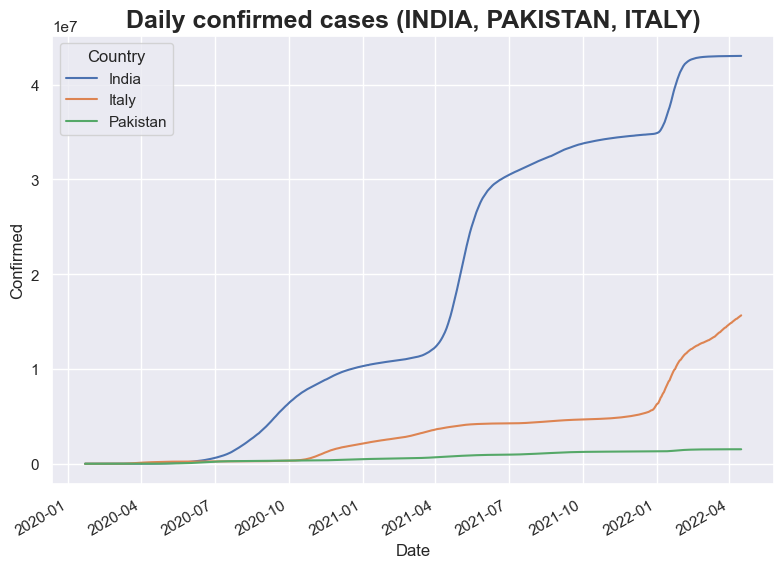

In [97]:
sns.set_theme(style='darkgrid')
plt.figure(figsize = (8,6))
sns.lineplot(data=multiple_country , x = 'Date' , y = 'Confirmed', hue='Country')
plt.title('Daily confirmed cases (INDIA, PAKISTAN, ITALY)', fontsize=18, fontweight='bold' )
plt.gcf().autofmt_xdate()  #kamaal function hai zyada data points ke liye
plt.tight_layout()
plt.show()

In [98]:
multiple_country[multiple_country['Date'] == multiple_country['Date'].max()]

,Date,Country,Confirmed,Recovered,Deaths,Daily_cases
66095,2022-04-16,India,43042097,0,521751,1150.0
70991,2022-04-16,Italy,15659835,0,161602,64533.0
110159,2022-04-16,Pakistan,1527248,0,30363,97.0


### Create a bar plot for deaths on the last date

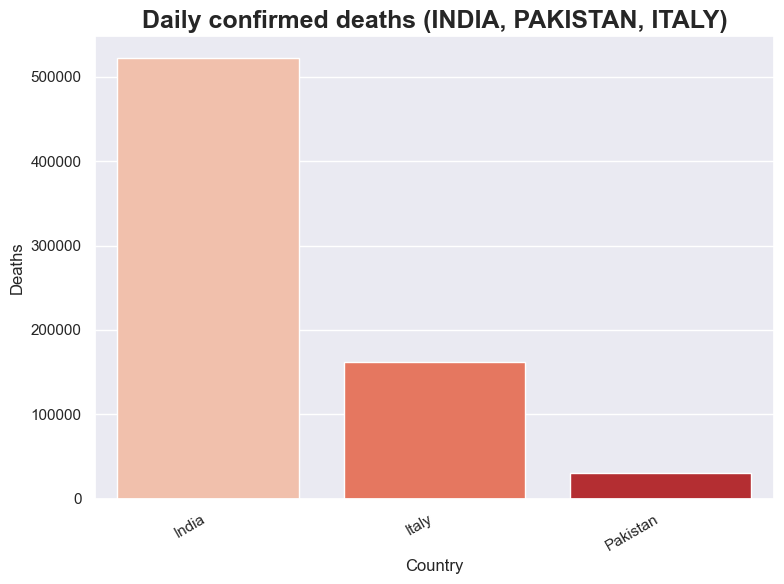

In [116]:
filter_deaths = multiple_country[multiple_country['Date'] == multiple_country['Date'].max()]
plt.figure(figsize = (8,6))
sns.barplot(data = filter_deaths , x = 'Country', y='Deaths', hue='Country', palette='Reds')
plt.title('Daily confirmed deaths (INDIA, PAKISTAN, ITALY)', fontsize=18, fontweight='bold' )
plt.gcf().autofmt_xdate()  #kamaal function hai zyada data points ke liye
plt.tight_layout()
plt.show()

### Create a bar plot for recoveries on the last date

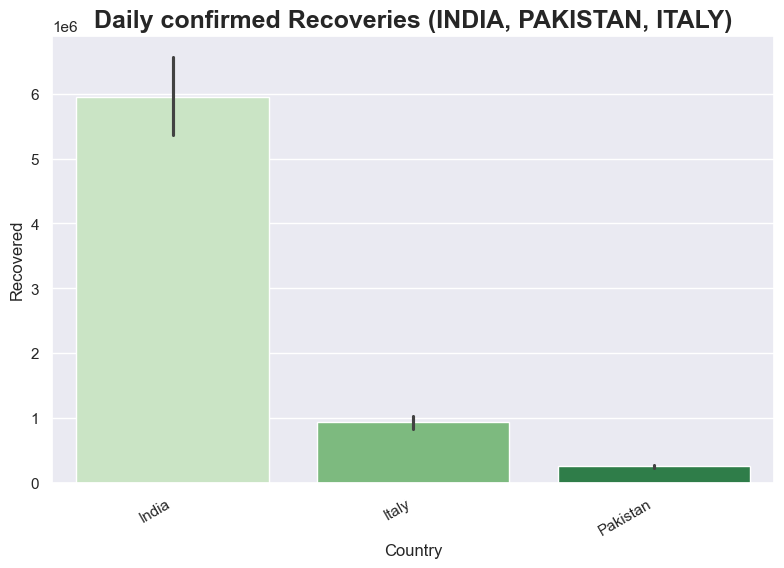

In [117]:
plt.figure(figsize = (8,6))
sns.barplot(data = multiple_country, x = 'Country', y='Recovered', hue='Country', palette='Greens')
plt.title('Daily confirmed Recoveries (INDIA, PAKISTAN, ITALY)', fontsize=18, fontweight='bold' )
plt.gcf().autofmt_xdate()  #kamaal function hai zyada data points ke liye
plt.tight_layout()
plt.show()

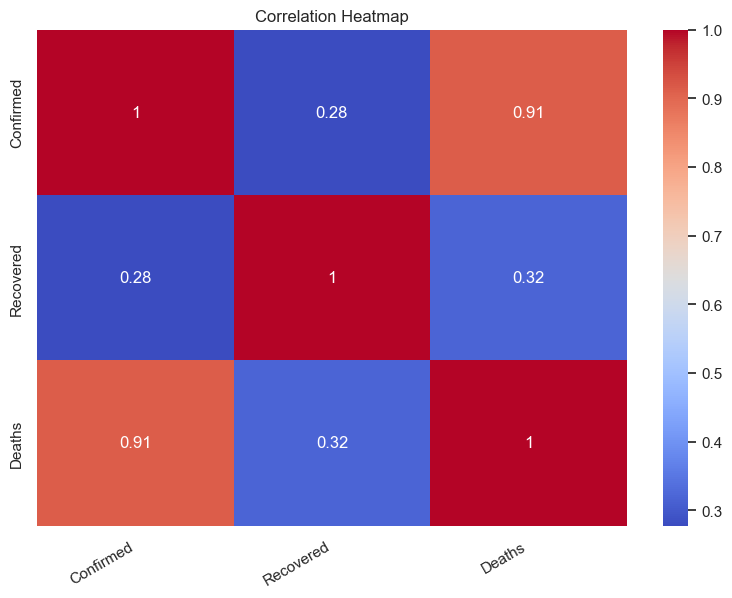

In [119]:
plt.figure(figsize = (8,6))
corr = df[["Confirmed", "Recovered", "Deaths"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.gcf().autofmt_xdate()  #kamaal function hai zyada data points ke liye
plt.tight_layout()
plt.title("Correlation Heatmap")
plt.show()